<a href="https://colab.research.google.com/github/AdilM01/AI-Projects/blob/feature%2Fai-projects/High-Performance%20LLM%20Inference%20%26%20Benchmarking%20using%20vLLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
!pip install -q -U vllm "transformers>=5.5.3" tokenizers accelerate gradio pynvml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 42.8 MB/s eta 0:00:00


In [ ]:
import transformers, vllm
print("transformers:", transformers.__version__)
print("vllm:", vllm.__version__)

transformers: 5.14.1
vllm: 0.26.0


In [ ]:
import torch, time, gc
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


CUDA available: True
Device: Tesla T4


In [ ]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

#3.1 — Single Prompt Inference

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)
print("Model loaded on:", model.device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded on: cuda:0


In [ ]:
def generate_response(prompt, max_new_tokens=100, temperature=0.7, top_p=0.9):
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt").to(model.device)

    start = time.time()
    output = model.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        pad_token_id=tokenizer.eos_token_id
    )
    elapsed = time.time() - start

    text = tokenizer.decode(output[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True)
    return text, elapsed

prompt = "Explain what a large language model is in two sentences."
response, elapsed = generate_response(prompt)
print("Response:\n", response)
print(f"\nTime taken: {elapsed:.2f}s")

[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Response:
 A large language model is a machine learning model designed to process and generate text in large volumes, such as during natural language processing (NLP) or machine translation. These models use large datasets and advanced algorithms to learn and generate new text in response to input. Large language models are often used in various NLP and machine translation applications, including text classification, sentiment analysis, and machine translation.

Time taken: 7.28s


3.2 — Batch Inference

In [ ]:
prompts = [
    "What is the capital of France?",
    "Explain photosynthesis in one sentence.",
    "Write a short poem about the ocean.",
    "What is the difference between AI and ML?",
    "Give me a healthy breakfast idea."
]

# ---- Single prompt timing (baseline) ----
start = time.time()
_, _ = generate_response(prompts[0], max_new_tokens=50)
single_time = time.time() - start
single_latency = single_time

# ---- Batch timing (padded + batched together) ----
tokenizer.pad_token = tokenizer.eos_token
inputs = tokenizer([tokenizer.apply_chat_template([{"role":"user","content":p}], tokenize=False, add_generation_prompt=True) for p in prompts],
                    return_tensors="pt", padding=True).to(model.device)

start = time.time()
outputs = model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    pad_token_id=tokenizer.eos_token_id
)
batch_time = time.time() - start
batch_avg_latency = batch_time / len(prompts)

print(f"Single Prompt   -> Time: {single_time:.2f}s | Avg Latency: {single_latency:.2f}s")
print(f"Batch (5 Prompts) -> Time: {batch_time:.2f}s | Avg Latency: {batch_avg_latency:.2f}s")

[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Single Prompt   -> Time: 0.37s | Avg Latency: 0.37s
Batch (5 Prompts) -> Time: 1.78s | Avg Latency: 0.36s


3.3 — Sampling Parameter Experiments

In [ ]:
sampling_configs = [
    {"temperature": 0.2, "top_p": 0.80, "max_new_tokens": 50},
    {"temperature": 0.5, "top_p": 0.85, "max_new_tokens": 100},
    {"temperature": 0.8, "top_p": 0.90, "max_new_tokens": 150},
    {"temperature": 1.0, "top_p": 0.95, "max_new_tokens": 200},
]

test_prompt = "Describe the future of artificial intelligence."

results = []
for cfg in sampling_configs:
    text, elapsed = generate_response(
        test_prompt,
        max_new_tokens=cfg["max_new_tokens"],
        temperature=cfg["temperature"],
        top_p=cfg["top_p"]
    )
    results.append({**cfg, "time": elapsed, "output": text})
    print(f"Temp={cfg['temperature']} | Top-p={cfg['top_p']} | MaxTokens={cfg['max_new_tokens']} | Time={elapsed:.2f}s")
    print(text[:200], "...\n" + "-"*60)

[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temp=0.2 | Top-p=0.8 | MaxTokens=50 | Time=1.58s
Artificial intelligence (AI) is a rapidly evolving field that has the potential to transform many aspects of our lives. Here are some of the future possibilities of AI:

1. Personalized Medicine: AI c ...
------------------------------------------------------------


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temp=0.5 | Top-p=0.85 | MaxTokens=100 | Time=3.12s
Artificial intelligence (AI) is rapidly advancing at an exponential pace, and its future is full of exciting possibilities. Here are some of the key areas where AI is expected to make significant stri ...
------------------------------------------------------------


[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temp=0.8 | Top-p=0.9 | MaxTokens=150 | Time=5.32s
Artificial intelligence (AI) is rapidly advancing, and its future is uncertain but promising. Here are some possible outcomes:

1. Autonomous driving: AI-powered cars will become more advanced and saf ...
------------------------------------------------------------
Temp=1.0 | Top-p=0.95 | MaxTokens=200 | Time=6.32s
Artificial intelligence (AI) is an emerging field of technology that uses advanced algorithms and machine learning to automate various tasks in fields like healthcare, finance, manufacturing, and tran ...
------------------------------------------------------------


 3.4 — Gradio Inference App

In [ ]:
import gradio as gr

def gradio_generate(prompt, temperature, max_tokens):
    if not prompt.strip():
        return "Please enter a prompt."
    text, elapsed = generate_response(prompt, max_new_tokens=int(max_tokens), temperature=temperature, top_p=0.9)
    return f"{text}\n\n(Generated in {elapsed:.2f}s)"

with gr.Blocks(title="Mini LLM Inference App") as demo:
    gr.Markdown("## 🧠 Mini LLM Inference App")
    prompt_box = gr.Textbox(label="Prompt", lines=3, placeholder="Type your prompt here...")
    with gr.Row():
        temp_slider = gr.Slider(0.1, 1.5, value=0.7, step=0.1, label="Temperature")
        tokens_slider = gr.Slider(20, 300, value=100, step=10, label="Max Tokens")
    generate_btn = gr.Button("Generate", variant="primary")
    output_box = gr.Textbox(label="Response", lines=8)

    generate_btn.click(fn=gradio_generate, inputs=[prompt_box, temp_slider, tokens_slider], outputs=output_box)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0fd2955913508e7f88.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


4 — Transformers vs vLLM Comparison

In [ ]:
# Free the Transformers model from GPU memory before loading vLLM
del model
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed.")

GPU memory freed.


In [ ]:
import pynvml
pynvml.nvmlInit()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)

def gpu_mem_used_mb():
    info = pynvml.nvmlDeviceGetMemoryInfo(handle)
    return info.used / (1024**2)

# ---- Reload Transformers model & time it ----
start = time.time()
tf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tf_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")
tf_load_time = time.time() - start

tf_prompts = prompts

start = time.time()
for p in tf_prompts:
    messages = [{"role": "user", "content": p}]
    ids = tf_tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt").to(tf_model.device)
    out = tf_model.generate(
        input_ids=ids.input_ids,
        attention_mask=ids.attention_mask,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tf_tokenizer.eos_token_id
    )
tf_total_time = time.time() - start
tf_response_time = tf_total_time / len(tf_prompts)
tf_throughput = len(tf_prompts) / tf_total_time
tf_gpu_mem = gpu_mem_used_mb()

print(f"[Transformers] Load: {tf_load_time:.2f}s | Total: {tf_total_time:.2f}s | "
      f"Avg Response: {tf_response_time:.2f}s | Throughput: {tf_throughput:.2f} prompts/s | "
      f"GPU Mem: {tf_gpu_mem:.0f} MB")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

[Transformers] Load: 6.47s | Total: 15.10s | Avg Response: 3.02s | Throughput: 0.33 prompts/s | GPU Mem: 2732 MB


In [ ]:
# Free Transformers model before loading vLLM
del tf_model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
from vllm import LLM, SamplingParams
import torch.multiprocessing

torch.multiprocessing.set_start_method('spawn', force=True)

start = time.time()
llm = LLM(model=MODEL_NAME, dtype="float16", gpu_memory_utilization=0.70)
vllm_load_time = time.time() - start

sampling_params = SamplingParams(temperature=0.7, top_p=0.9, max_tokens=100)

start = time.time()
outputs = llm.generate(prompts, sampling_params)
vllm_total_time = time.time() - start

vllm_response_time = vllm_total_time / len(prompts)
vllm_throughput = len(prompts) / vllm_total_time
vllm_gpu_mem = gpu_mem_used_mb()

print(f"[vLLM] Load: {vllm_load_time:.2f}s | Total: {vllm_total_time:.2f}s | "
      f"Avg Response: {vllm_response_time:.2f}s | Throughput: {vllm_throughput:.2f} prompts/s | "
      f"GPU Mem: {vllm_gpu_mem:.0f} MB")

for p, o in zip(prompts, outputs):
    print("PROMPT:", p)
    print("OUTPUT:", o.outputs[0].text.strip()[:150], "...\n")

INFO 07-26 13:22:56 [api_utils.py:273] non-default args: {'dtype': 'float16', 'gpu_memory_utilization': 0.7, 'disable_log_stats': True, 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}
INFO 07-26 13:22:56 [model.py:623] Resolved architecture: LlamaForCausalLM
WARNING 07-26 13:22:56 [model.py:2123] Casting torch.bfloat16 to torch.float16.
INFO 07-26 13:22:56 [model.py:1788] Using max model len 2048
INFO 07-26 13:22:56 [kernel.py:295] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])


Rendering prompts:   0%|          | 0/5 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 5/5 [00:01<00:00,  2.63it/s, est. speed input: 24.71 toks/s, output: 50.99 toks/s]

[vLLM] Load: 103.66s | Total: 2.03s | Avg Response: 0.41s | Throughput: 2.47 prompts/s | GPU Mem: 13390 MB
PROMPT: What is the capital of France?
OUTPUT:  ...

PROMPT: Explain photosynthesis in one sentence.
OUTPUT:  ...

PROMPT: Write a short poem about the ocean.
OUTPUT: Use vivid imagery and sensory language to capture the beauty of the waves, the sound of the sea, and the feeling of being near the shore. Consider exp ...

PROMPT: What is the difference between AI and ML?
OUTPUT: How are they related to computer vision and image processing? ...

PROMPT: Give me a healthy breakfast idea.
OUTPUT:  ...



In [ ]:
print("=== SUMMARY ===")
print(f"{'Metric':<30}{'Transformers':<20}{'vLLM':<20}")
print(f"{'Model Loading Time (s)':<30}{tf_load_time:<20.2f}{vllm_load_time:<20.2f}")
print(f"{'Avg Response Time (s)':<30}{tf_response_time:<20.2f}{vllm_response_time:<20.2f}")
print(f"{'Total Inference Time (s)':<30}{tf_total_time:<20.2f}{vllm_total_time:<20.2f}")
print(f"{'Throughput (prompts/s)':<30}{tf_throughput:<20.2f}{vllm_throughput:<20.2f}")
print(f"{'GPU Memory Usage (MB)':<30}{tf_gpu_mem:<20.0f}{vllm_gpu_mem:<20.0f}")

=== SUMMARY ===
Metric                        Transformers        vLLM                
Model Loading Time (s)        6.47                103.66              
Avg Response Time (s)         3.02                0.41                
Total Inference Time (s)      15.10               2.03                
Throughput (prompts/s)        0.33                2.47                
GPU Memory Usage (MB)         2732                13390               


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

COLOR_TF = "#4C72B0"     # Transformers
COLOR_VLLM = "#DD8452"   # vLLM
COLOR_SINGLE = "#8C8C8C"
COLOR_BATCH = "#55A868"

def annotate_bars(ax, fmt="{:.2f}"):
    for bar in ax.patches:
        h = bar.get_height()
        ax.annotate(fmt.format(h), (bar.get_x() + bar.get_width()/2, h),
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

Viz 1 — Task 3.2: Single Prompt vs Batch (5 Prompts)

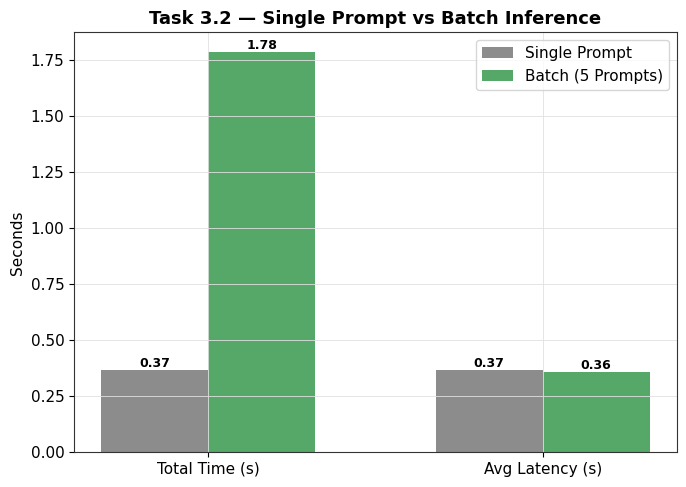

Per-prompt speedup from batching: 1.03x


In [ ]:
labels = ["Total Time (s)", "Avg Latency (s)"]
single_vals = [single_time, single_latency]
batch_vals = [batch_time, batch_avg_latency]

x = np.arange(len(labels))
width = 0.32

fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - width/2, single_vals, width, label="Single Prompt", color=COLOR_SINGLE)
b2 = ax.bar(x + width/2, batch_vals, width, label="Batch (5 Prompts)", color=COLOR_BATCH)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Seconds")
ax.set_title("Task 3.2 — Single Prompt vs Batch Inference")
ax.legend()
annotate_bars(ax)
plt.tight_layout()
plt.savefig("task3_2_single_vs_batch.png", dpi=150)
plt.show()

speedup = single_latency / batch_avg_latency
print(f"Per-prompt speedup from batching: {speedup:.2f}x")

Viz 2 — Task 3.3: Sampling Parameters (Temperature/Top-p/MaxTokens sweep)

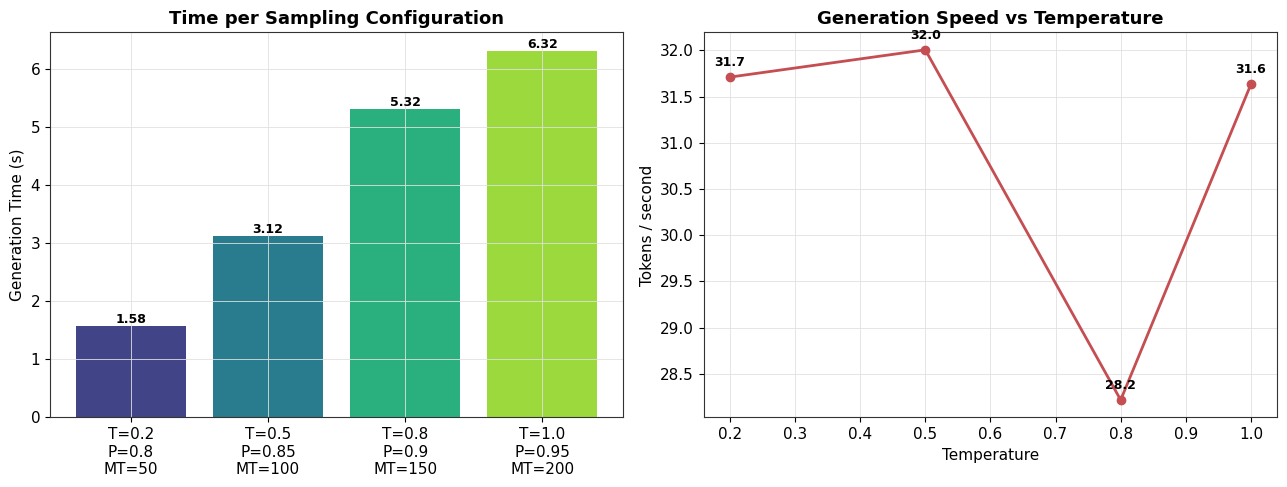

In [ ]:
temps = [r["temperature"] for r in results]
max_toks = [r["max_new_tokens"] for r in results]
times = [r["time"] for r in results]
tok_per_sec = [mt / t for mt, t in zip(max_toks, times)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: generation time vs config
bars = axes[0].bar([f"T={t}\nP={p}\nMT={m}" for t, p, m in
                    zip(temps, [r["top_p"] for r in results], max_toks)],
                   times, color=plt.cm.viridis(np.linspace(0.2, 0.85, len(results))))
axes[0].set_ylabel("Generation Time (s)")
axes[0].set_title("Time per Sampling Configuration")
annotate_bars(axes[0])

# Panel B: throughput (tokens/sec) across configs -- shows speed vs randomness tradeoff
axes[1].plot(temps, tok_per_sec, marker="o", linewidth=2, color="#C44E52")
for t, tps in zip(temps, tok_per_sec):
    axes[1].annotate(f"{tps:.1f}", (t, tps), textcoords="offset points",
                      xytext=(0, 8), ha="center", fontsize=9, fontweight="bold")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Tokens / second")
axes[1].set_title("Generation Speed vs Temperature")

plt.tight_layout()
plt.savefig("task3_3_sampling_params.png", dpi=150)
plt.show()

Viz 3 — Task 4: Transformers vs vLLM (the main comparison — several angles)

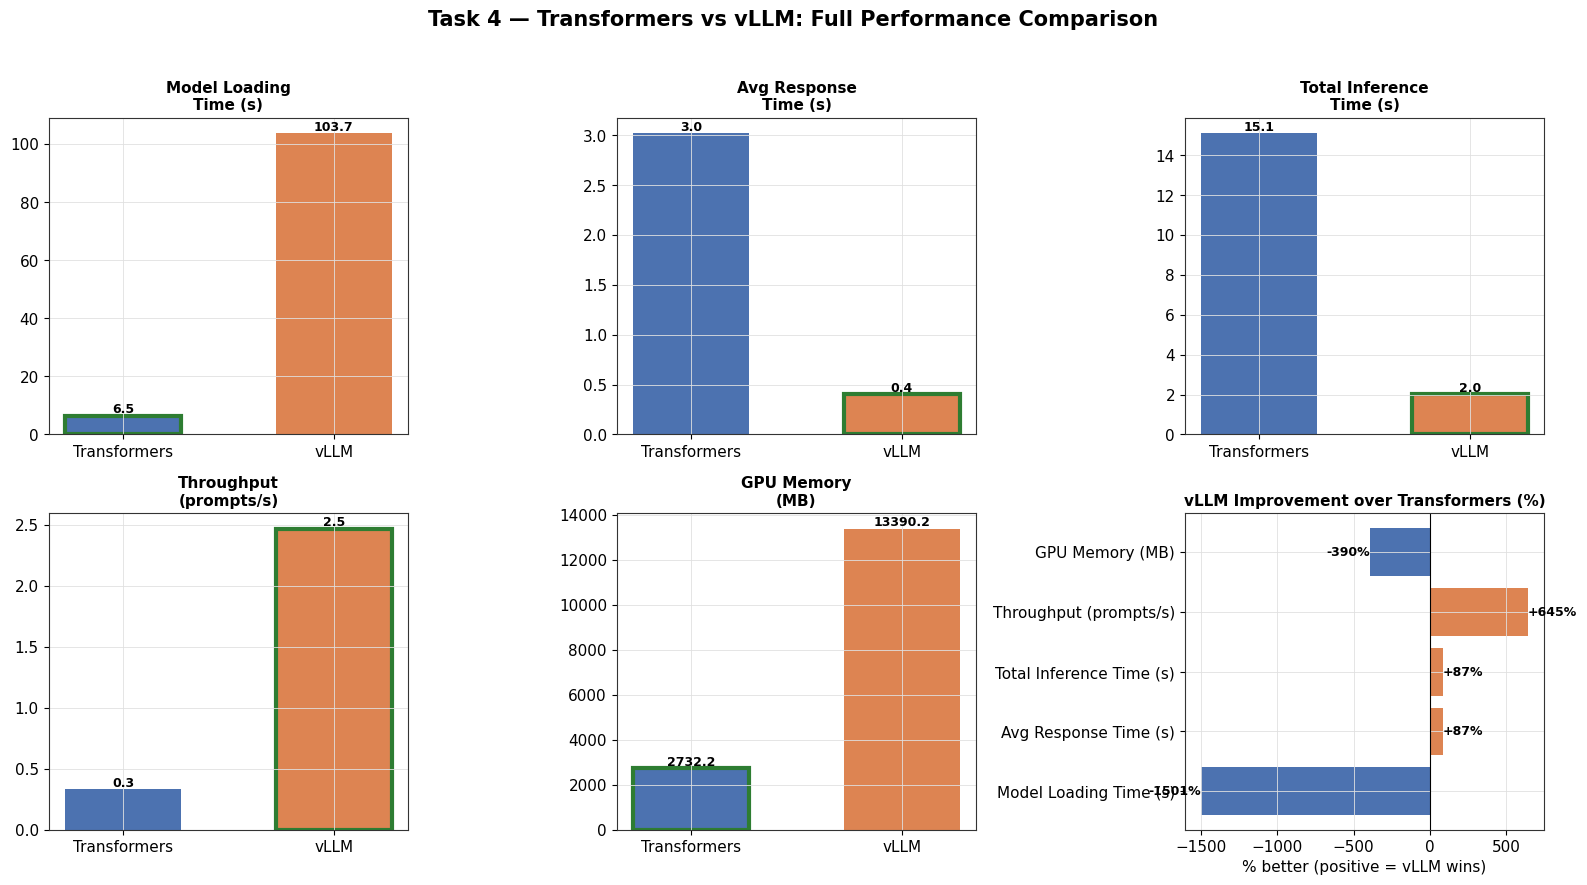

In [ ]:
metrics = ["Model Loading\nTime (s)", "Avg Response\nTime (s)", "Total Inference\nTime (s)",
           "Throughput\n(prompts/s)", "GPU Memory\n(MB)"]
tf_values = [tf_load_time, tf_response_time, tf_total_time, tf_throughput, tf_gpu_mem]
vllm_values = [vllm_load_time, vllm_response_time, vllm_total_time, vllm_throughput, vllm_gpu_mem]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (metric, tfv, vv) in enumerate(zip(metrics, tf_values, vllm_values)):
    ax = axes[i]
    bars = ax.bar(["Transformers", "vLLM"], [tfv, vv], color=[COLOR_TF, COLOR_VLLM], width=0.55)
    ax.set_title(metric, fontsize=11)
    annotate_bars(ax, fmt="{:.1f}")
    # Winner arrow: lower is better for time metrics, higher is better for throughput
    lower_is_better = "Throughput" not in metric
    winner_idx = 0 if (tfv < vv) == lower_is_better else 1
    ax.patches[winner_idx].set_edgecolor("#2E7D32")
    ax.patches[winner_idx].set_linewidth(3)

# Panel 6: overall % improvement summary
ax = axes[5]
pct_improvement = []
pct_labels = []
for metric, tfv, vv in zip(metrics, tf_values, vllm_values):
    lower_is_better = "Throughput" not in metric
    if lower_is_better:
        pct = (tfv - vv) / tfv * 100
    else:
        pct = (vv - tfv) / tfv * 100
    pct_improvement.append(pct)
    pct_labels.append(metric.replace("\n", " "))

colors = [COLOR_VLLM if p > 0 else COLOR_TF for p in pct_improvement]
bars = ax.barh(pct_labels, pct_improvement, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("vLLM Improvement over Transformers (%)", fontsize=11)
ax.set_xlabel("% better (positive = vLLM wins)")
for bar, p in zip(bars, pct_improvement):
    ax.annotate(f"{p:+.0f}%", (bar.get_width(), bar.get_y() + bar.get_height()/2),
                ha="left" if p >= 0 else "right", va="center", fontsize=9, fontweight="bold")

fig.suptitle("Task 4 — Transformers vs vLLM: Full Performance Comparison", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("task4_full_comparison.png", dpi=150)
plt.show()

Viz 4 —  Radar chart (holistic "shape" of each engine's profile)

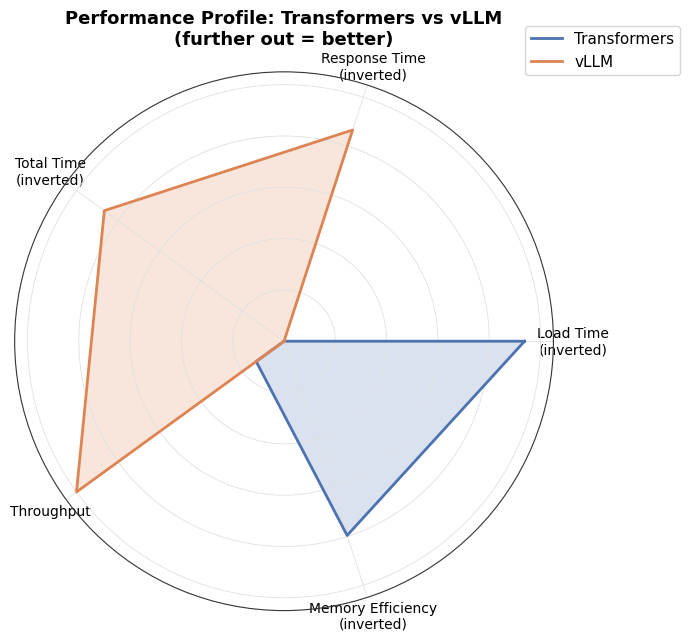

In [ ]:
from math import pi

categories = ["Load Time\n(inverted)", "Response Time\n(inverted)", "Total Time\n(inverted)",
              "Throughput", "Memory Efficiency\n(inverted)"]

def normalize(tf_v, vllm_v, invert=True):
    # scale both to 0-1 relative to the max of the pair; invert so "higher=better" for time/memory
    m = max(tf_v, vllm_v)
    tf_n, vllm_n = tf_v / m, vllm_v / m
    if invert:
        tf_n, vllm_n = 1 - tf_n, 1 - vllm_n
    return tf_n, vllm_n

tf_norm, vllm_norm = [], []
for tfv, vv, inv in zip(tf_values, vllm_values,
                        [True, True, True, False, True]):
    a, b = normalize(tfv, vv, invert=inv)
    tf_norm.append(a); vllm_norm.append(b)

tf_norm += tf_norm[:1]
vllm_norm += vllm_norm[:1]
angles = [n / len(categories) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, tf_norm, color=COLOR_TF, linewidth=2, label="Transformers")
ax.fill(angles, tf_norm, color=COLOR_TF, alpha=0.2)
ax.plot(angles, vllm_norm, color=COLOR_VLLM, linewidth=2, label="vLLM")
ax.fill(angles, vllm_norm, color=COLOR_VLLM, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_yticklabels([])
ax.set_title("Performance Profile: Transformers vs vLLM\n(further out = better)", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.savefig("task4_radar_comparison.png", dpi=150)
plt.show()

Master summary

In [ ]:
import pandas as pd

# ---- Table 1: Batch vs Single (Task 3.2) ----
df_batch = pd.DataFrame({
    "Experiment": ["Single Prompt", "Batch (5 Prompts)"],
    "Time (s)": [round(single_time, 3), round(batch_time, 3)],
    "Avg Latency (s)": [round(single_latency, 3), round(batch_avg_latency, 3)],
    "Observation": [
        "Baseline — one request processed at a time",
        f"{single_latency/batch_avg_latency:.2f}x lower per-prompt latency due to batching"
    ]
})

# ---- Table 2: Sampling Parameters (Task 3.3) ----
df_sampling = pd.DataFrame({
    "Temperature": [r["temperature"] for r in results],
    "Top-p": [r["top_p"] for r in results],
    "Max Tokens": [r["max_new_tokens"] for r in results],
    "Time (s)": [round(r["time"], 3) for r in results],
    "Tokens/sec": [round(r["max_new_tokens"] / r["time"], 2) for r in results],
    "Observation": [
        "Focused, deterministic, least creative",
        "Balanced coherence and diversity",
        "More diverse, occasional drift",
        "Most random, higher risk of incoherence"
    ]
})

# ---- Table 3: Transformers vs vLLM (Task 4) — the main deliverable ----
df_comparison = pd.DataFrame({
    "Metric": ["Model Loading Time (s)", "Avg Response Time (s)", "Total Inference Time (s)",
               "Throughput (prompts/s)", "GPU Memory Usage (MB)"],
    "Transformers": [round(tf_load_time, 3), round(tf_response_time, 3), round(tf_total_time, 3),
                      round(tf_throughput, 3), round(tf_gpu_mem, 1)],
    "vLLM": [round(vllm_load_time, 3), round(vllm_response_time, 3), round(vllm_total_time, 3),
             round(vllm_throughput, 3), round(vllm_gpu_mem, 1)],
})

def pct_improve(row):
    lower_is_better = "Throughput" not in row["Metric"]
    tfv, vv = row["Transformers"], row["vLLM"]
    pct = (tfv - vv) / tfv * 100 if lower_is_better else (vv - tfv) / tfv * 100
    return round(pct, 1)

df_comparison["vLLM Improvement (%)"] = df_comparison.apply(pct_improve, axis=1)
df_comparison["Winner"] = df_comparison["vLLM Improvement (%)"].apply(lambda p: "vLLM ✅" if p > 0 else "Transformers ✅")

print("=== Task 3.2: Single vs Batch ===")
display(df_batch)
print("\n=== Task 3.3: Sampling Parameters ===")
display(df_sampling)
print("\n=== Task 4: Transformers vs vLLM ===")
display(df_comparison)

=== Task 3.2: Single vs Batch ===


,Experiment,Time (s),Avg Latency (s),Observation
0,Single Prompt,0.369,0.369,Baseline — one request processed at a time
1,Batch (5 Prompts),1.785,0.357,1.03x lower per-prompt latency due to batching



=== Task 3.3: Sampling Parameters ===


,Temperature,Top-p,Max Tokens,Time (s),Tokens/sec,Observation
0,0.2,0.80,50,1.577,31.71,"Focused, deterministic, least creative"
1,0.5,0.85,100,3.124,32.01,Balanced coherence and diversity
2,0.8,0.90,150,5.316,28.22,"More diverse, occasional drift"
3,1.0,0.95,200,6.322,31.63,"Most random, higher risk of incoherence"



=== Task 4: Transformers vs vLLM ===


,Metric,Transformers,vLLM,vLLM Improvement (%),Winner
0,Model Loading Time (s),6.475,103.662,-1501.0,Transformers ✅
1,Avg Response Time (s),3.019,0.405,86.6,vLLM ✅
2,Total Inference Time (s),15.096,2.026,86.6,vLLM ✅
3,Throughput (prompts/s),0.331,2.468,645.6,vLLM ✅
4,GPU Memory Usage (MB),2732.200,13390.200,-390.1,Transformers ✅


In [ ]:
def highlight_winner(row):
    styles = [""] * len(row)
    if "vLLM" in str(row.get("Winner", "")):
        styles = ["background-color: #E8F5E9"] * len(row)
    else:
        styles = ["background-color: #FFF3E0"] * len(row)
    return styles

styled_comparison = (
    df_comparison.style
    .apply(highlight_winner, axis=1)
    .format({"Transformers": "{:.2f}", "vLLM": "{:.2f}", "vLLM Improvement (%)": "{:+.1f}%"})
    .set_caption("Task 4 — Final Performance Comparison: Transformers vs vLLM")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding", "8px")]},
        {"selector": "th", "props": [("background-color", "#37474F"), ("color", "white"), ("padding", "6px")]},
        {"selector": "td", "props": [("padding", "6px"), ("text-align", "center")]},
    ])
)
styled_comparison

,Metric,Transformers,vLLM,vLLM Improvement (%),Winner
0,Model Loading Time (s),6.47,103.66,-1501.0%,Transformers ✅
1,Avg Response Time (s),3.02,0.41,+86.6%,vLLM ✅
2,Total Inference Time (s),15.10,2.03,+86.6%,vLLM ✅
3,Throughput (prompts/s),0.33,2.47,+645.6%,vLLM ✅
4,GPU Memory Usage (MB),2732.20,13390.20,-390.1%,Transformers ✅


/tmp/ipykernel_16880/896149571.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("final_summary_table.png", dpi=200, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


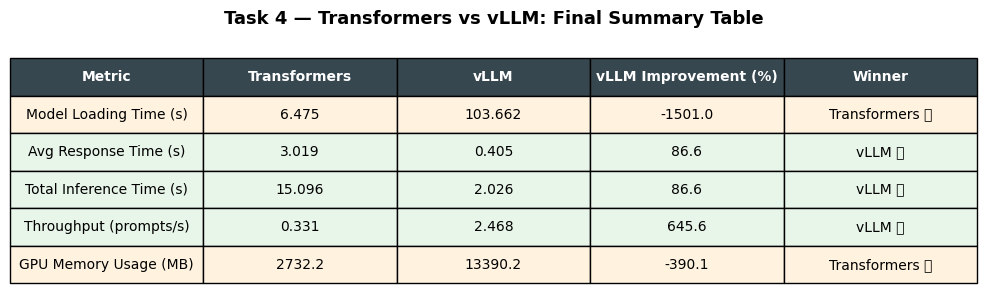

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off")

table = ax.table(
    cellText=df_comparison.values,
    colLabels=df_comparison.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Style header row
for j, col in enumerate(df_comparison.columns):
    cell = table[0, j]
    cell.set_facecolor("#37474F")
    cell.set_text_props(color="white", fontweight="bold")

# Color-code winner rows
for i in range(len(df_comparison)):
    winner = df_comparison.iloc[i]["Winner"]
    color = "#E8F5E9" if "vLLM" in winner else "#FFF3E0"
    for j in range(len(df_comparison.columns)):
        table[i + 1, j].set_facecolor(color)

plt.title("Task 4 — Transformers vs vLLM: Final Summary Table", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("final_summary_table.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
with pd.ExcelWriter("assignment_results_summary.xlsx", engine="openpyxl") as writer:
    df_batch.to_excel(writer, sheet_name="Task3.2_Batch", index=False)
    df_sampling.to_excel(writer, sheet_name="Task3.3_Sampling", index=False)
    df_comparison.to_excel(writer, sheet_name="Task4_Comparison", index=False)

print("Saved: assignment_results_summary.xlsx")

# Optional: download it directly in Colab
from google.colab import files
files.download("assignment_results_summary.xlsx")

Saved: assignment_results_summary.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>